In [1]:
!pip install ultralytics roboflow

  Using cached idna-3.7-py3-none-any.whl.metadata (9.9 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
Using cached idna-3.7-py3-none-any.whl (66 kB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)
Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl (54 kB)

   ---------------------------------------- 0/4 [opencv-python-headless]
   ---------------------------------------- 0/4 [opencv-python-headless]
   ---------------------------------------- 0/4 [opencv-python-headless]
  Attempting uninstall: idna
   ---------------------------------------- 0/4 [opencv-python-headless]
    Found existing installation: idna 3.10
   ---------------------------------------- 0/4 [opencv-python-headless]
    Uninstalling idna-3.10:
   ---------------------------------------- 0/4 [opencv-python-headless]
      Successfully uninstalled idna-3.10
  

In [2]:
from ultralytics import YOLO
from roboflow import Roboflow

In [3]:
!pip install roboflow

In [4]:

from roboflow import Roboflow
rf = Roboflow(api_key="bgX7yTmpVHMEXCKqbm93")
project = rf.workspace("joseph-bygbd").project("dspnameplatev8-objects-visibilit-g0zrh")
version = project.version(2)
dataset = version.download("yolov8")
                
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dspNamePlateV8-objects-Visibilit-2 in yolov8:: 100%|██████████| 75/75 [00:00<00:00, 2235.82it/s]


In [5]:
import cv2
from ultralytics import YOLO
#import numpy as np
import matplotlib.pyplot as plt

In [13]:
from ultralytics import YOLO

# Load the nano model (very lightweight)
model = YOLO("yolov8l.pt")

# Train the model using the correct path to data.yaml
model.train(
    data=r"C:\Users\Username\Documents\GitHub\dspCPE4A2526\dspPython\activity9\plate\data.yaml",
    epochs=20,
    imgsz=416,          # Smaller image size saves RAM
    batch=8,            # Lower batch for low RAM
    plots=True
)


New https://pypi.org/project/ultralytics/8.3.221 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.202  Python-3.13.7 torch-2.8.0+cpu CPU (AMD Ryzen 7 3800X 8-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Username\Documents\GitHub\dspCPE4A2526\dspPython\activity9\plate\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000023F6872CE10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0


image 1/1 c:\Users\Username\Documents\GitHub\dspCPE4A2526\dspPython\activity9\name.jpg: 416x320 2 Texts, 154.1ms
Speed: 1.0ms preprocess, 154.1ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 320)


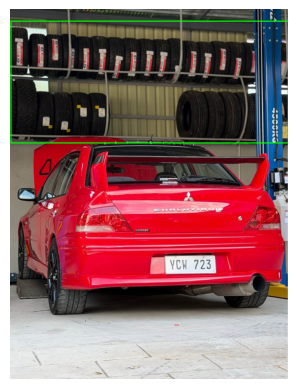

Detected Plate: LE
No valid last digit found.


In [29]:
import os
import cv2
import pytesseract
import re
from matplotlib import pyplot as plt
from ultralytics import YOLO

# ✅ Set up Tesseract path (Windows only)
# Change this path if your Tesseract installation is in a different location
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# ✅ Use a raw string to avoid path errors with backslashes
model_path = r"runs\detect\train8\weights\best.pt"

# ✅ Check if model file exists
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found at: {model_path}")

# ✅ Load YOLO model
model = YOLO(model_path)

# ✅ Vehicle coding rules (example for traffic coding)
coding_rules = {
    (1, 2): "Monday",
    (3, 4): "Tuesday",
    (5, 6): "Wednesday",
    (7, 8): "Thursday",
    (9, 0): "Friday"
}

# ✅ Input image
image_path = "name.jpg"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found at: {image_path}")

# ✅ Run YOLO detection
results = model(image_path, conf=0.7)

# ✅ Read and draw detection box
img = cv2.imread(image_path)
img_draw = img.copy()

if len(results[0].boxes) > 0:
    # Get coordinates of the first detected box
    x1, y1, x2, y2 = map(int, results[0].boxes[0].xyxy[0])
    cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    # ✅ Crop and preprocess plate region
    plate = img[y1:y2, x1:x2]
    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # ✅ OCR configuration for alphanumeric plates
    config = '--psm 8 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

    # Extract text using pytesseract
    raw_text = pytesseract.image_to_string(thresh, config=config).strip()
    plate_num = re.sub(r'[^A-Z0-9]', '', raw_text.upper())

    print("Detected Plate:", plate_num)

    # ✅ Determine last digit and coding day
    if plate_num and plate_num[-1].isdigit():
        last_digit = int(plate_num[-1])
        for nums, day in coding_rules.items():
            if last_digit in nums:
                print("Last digit:", last_digit)
                print("Coding Day:", day)
                break
    else:
        print("No valid last digit found.")
else:
    print("No plate detected.")


In [27]:
pip install ultralytics opencv-python pytesseract matplotlib numpy


Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install pytesseract


Note: you may need to restart the kernel to use updated packages.


In [22]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"


In [19]:
%matplotlib inline

In [20]:
%matplotlib inline

import cv2
import pytesseract
import re
from matplotlib import pyplot as plt
from ultralytics import YOLO